In [1]:
import csv

with open('pollution_data.csv', 'r') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  # Skip header row
    ph_values = []
    i = 0
    while len(ph_values) < 12:  # Continue until we have 12 values
        try:
            row = next(csv_reader)
            if (i + 1) % 4 != 0:  # Skip every 4th line because diluted samples seem like outliers
                ph_values.append(float(row[5]))
            i += 1
        except StopIteration:
            break
print(len(ph_values))

concentrations = ph_values.copy()
print(concentrations)

#### IMPORTANT -----

# if concentrations don't come from csv file, they can be saved directly here in a list, 
# uncomment the next line in that case and put actual concentrations
#concentrations = [6.7, 7.8, 6.7, 7.8, 6.7, 7.8, 6.7, 7.8, 6.7, 7.8, 6.7, 7.8,]
#print(concentrations)


12
[4.4, 4.2926829268292686, 4.190476190476191, 4.7, 4.585365853658536, 4.476190476190476, 4.05, 3.951219512195122, 3.857142857142857, 3.625, 3.5365853658536586, 3.4523809523809526]


In [ ]:
import spectral.io.envi as envi
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cross_decomposition import PLSRegression

# Function to load HSI cube with all bands
def load_hsi_cube(header_file, data_file):
    data = envi.open(header_file, data_file)
    cube = data.load()
    return cube


# Load samples with different concentrations
cubes = {
    'sample_1': load_hsi_cube('swiss/1_1_00ml.hdr', 'swiss/1_1_00ml.bin'),
    'sample_2': load_hsi_cube('swiss/1_1_05ml.hdr', 'swiss/1_1_05ml.bin'),
    'sample_3': load_hsi_cube('swiss/1_1_10ml.hdr', 'swiss/1_1_10ml.bin'),
    'sample_4': load_hsi_cube('swiss/1_2_00ml.hdr', 'swiss/1_2_00ml.bin'),
    'sample_5': load_hsi_cube('swiss/1_2_05ml.hdr', 'swiss/1_2_05ml.bin'),
    'sample_6': load_hsi_cube('swiss/1_2_10ml.hdr', 'swiss/1_2_10ml.bin'),
    'sample_7': load_hsi_cube('swiss/1_3_00ml.hdr', 'swiss/1_3_00ml.bin'),
    'sample_8': load_hsi_cube('swiss/1_3_05ml.hdr', 'swiss/1_3_05ml.bin'),
    'sample_9': load_hsi_cube('swiss/1_3_10ml.hdr', 'swiss/1_3_10ml.bin'),
    'sample_10': load_hsi_cube('swiss/1_4_00ml.hdr', 'swiss/1_4_00ml.bin'),
    'sample_11': load_hsi_cube('swiss/1_4_05ml.hdr', 'swiss/1_4_05ml.bin'),
    'sample_12': load_hsi_cube('swiss/1_4_10ml.hdr', 'swiss/1_4_10ml.bin'),

}
# Print shapes to verify
for name, cube in cubes.items():
    print(f"{name} shape: {cube.shape}")

cube_1 = load_hsi_cube('swiss/1_1_00ml.hdr', 'swiss/1_1_00ml.bin')
print(f"sample_1 shape: {cube_1.shape}")
#print(cubes['sample_1']) # uncomment if you want to see how 1 sample looks like
height, width, bands = cubes['sample_1'].shape
print(f"Image dimensions:")
print(f"Width: {width} pixels")
print(f"Height: {height} pixels")

print(f"Number of spectral bands: {bands} wavelengths")
# different first and second dimensions are fine, they won't break the code, but different third dimension (number of wavelength bands) will


sample_1 shape: (55, 1020, 301)
sample_2 shape: (50, 1020, 301)
sample_3 shape: (50, 1020, 301)
sample_4 shape: (51, 1020, 301)
sample_5 shape: (45, 1020, 301)
sample_6 shape: (51, 1020, 301)
sample_7 shape: (46, 1020, 301)
sample_8 shape: (49, 1020, 301)
sample_9 shape: (51, 1020, 301)
sample_10 shape: (50, 1020, 301)
sample_11 shape: (50, 1020, 301)
sample_12 shape: (46, 1020, 301)
sample_1 shape: (55, 1020, 301)
Image dimensions:
Width: 1020 pixels
Height: 55 pixels
Number of spectral bands: 301 wavelengths


these next few cells until pls are not necessary for training, they are just for visualisation

In [6]:
import spectral.io.envi as envi
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cross_decomposition import PLSRegression
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d


# Split out the three processing steps
def normalize_spectrum(spectrum):
    """Normalize spectrum to 0-1 range"""
    return (spectrum - np.min(spectrum)) / (np.max(spectrum) - np.min(spectrum))

def apply_savgol_filter(spectrum):
    """Apply Savitzky-Golay smoothing"""
    return savgol_filter(spectrum, 15, 3)

def apply_noise_reduction(spectrum):
    """Apply Gaussian filter for noise reduction"""
    return gaussian_filter1d(spectrum, sigma=1)


def process_spectrum(spectrum): # without visualisation
    """Apply all processing steps to spectrum without visualization
    
    Returns:
        tuple: (normalized, smoothed, denoised) versions of the spectrum
    """
    normalized = normalize_spectrum(spectrum)
    smoothed = apply_savgol_filter(normalized)
    denoised = apply_noise_reduction(smoothed)
    return normalized, smoothed, denoised

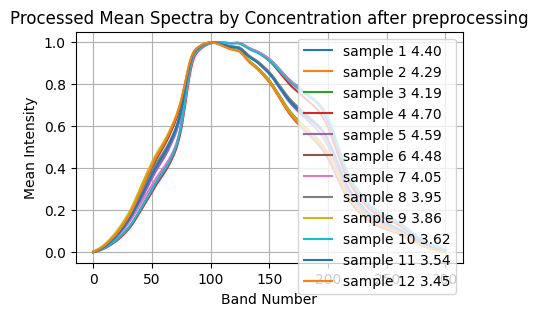

In [7]:
# visualise only mean preprocessed spectra of all cubes
# preprocessed means that it is normalised, smoothed with Savitsky-Golay filter and noise reduction is done

def view_processed_spectrum(cubes, concentrations):
    """View processed mean spectra for all cubes
    
    Args:
        cubes: Dictionary of all HSI cubes
        concentrations: List of concentration values
    """
    plt.figure(figsize=(5, 3))
    
    for (name, cube), conc_value in zip(cubes.items(), concentrations):
        # Calculate mean spectrum
        # mean spectrum means that for each wavelength there is not a 2D array of (x,y) pixels 
        # but only a mean of this 2D array with a mean of all pixels for this particular wavelength
        # this decision might be not optimal, but in this implementation that's how it goes
        # it is justified that mean for each wavelength is fine, because if all pixels have high intensity, then mean is high,
        # and if pixels have low and high intensity, mean will be somewhere in the middle
        # so in that way mean reduces information to just one value that represents all values for this wavelength
        mean_spectrum = np.mean(cube.reshape(-1, cube.shape[2]), axis=0)
        
        # Process the spectrum
        _, _, denoised = process_spectrum(mean_spectrum)
        
        # Plot the denoised spectrum
        sample_num = int(name.split('_')[1])
        plt.plot(range(cube.shape[2]), denoised, '-', 
                label=f'sample {sample_num} {conc_value:.2f}')
    
    plt.xlabel('Band Number')
    plt.ylabel('Mean Intensity')
    plt.title('Processed Mean Spectra by Concentration after preprocessing')
    # but white and black correction is not applied here as this plot just gives an idea what data looks like
    plt.legend()
    plt.grid(True)
    plt.show()

view_processed_spectrum(cubes, concentrations)

In [6]:

# visualise all cubes and all spectra 
def process_and_visualize_spectrum(spectrum, wavelengths, title_prefix=""):
    """Process spectrum with multiple steps and create visualizations"""
    # Create figure with subplots
    plt.figure(figsize=(6, 3))
    
    # Original spectrum
    plt.subplot(221)
    plt.plot(wavelengths, spectrum, 'b-', linewidth=1)
    plt.title(f'{title_prefix}\nOriginal', fontsize=8)
    plt.xlabel('Wavelength (nm)', fontsize=8)
    plt.ylabel('Intensity', fontsize=8)
    plt.tick_params(axis='both', which='major', labelsize=6)
    
    # Normalized spectrum
    normalized = normalize_spectrum(spectrum)
    plt.subplot(222)
    plt.plot(wavelengths, normalized, 'g-', linewidth=1)
    plt.title('Normalized', fontsize=8)
    plt.xlabel('Wavelength (nm)', fontsize=8)
    plt.ylabel('Intensity (norm.)', fontsize=8)
    plt.tick_params(axis='both', which='major', labelsize=6)
    
    # Savitzky-Golay smoothing
    smoothed = savgol_filter(normalized, 15, 3)  # window_length=5
    plt.subplot(223)
    plt.plot(wavelengths, smoothed, 'r-', linewidth=1)
    plt.title('Savitzky-Golay\nSmoothed', fontsize=8)
    plt.xlabel('Wavelength (nm)', fontsize=8)
    plt.ylabel('Intensity (norm.)', fontsize=8)
    plt.tick_params(axis='both', which='major', labelsize=6)
    
    # Noise reduction with Gaussian filter
    denoised = gaussian_filter1d(smoothed, sigma=1)
    plt.subplot(224)
    plt.plot(wavelengths, denoised, 'm-', linewidth=1)
    plt.title('Noise Reduced', fontsize=8)
    plt.xlabel('Wavelength (nm)', fontsize=8)
    plt.ylabel('Intensity (norm.)', fontsize=8)
    plt.tick_params(axis='both', which='major', labelsize=6)
    
    plt.tight_layout()
    plt.show()
    
    return normalized, smoothed, denoised

def plot_mean_spectra(cubes):
    plt.figure(figsize=(5, 3))
    
    for (name, cube), conc_value in zip(cubes.items(), concentrations):
        # Calculate mean across spatial dimensions
        mean_spectrum = np.mean(cube.reshape(-1, cube.shape[2]), axis=0)
        sample_num = int(name.split('_')[1])  # Get sample number from name
        plt.plot(range(cube.shape[2]), mean_spectrum, '-', 
                label=f'sample {sample_num} {conc_value:.2f}')
    
    plt.xlabel('Band Number')
    plt.ylabel('Mean Intensity')
    plt.title('Mean Spectra by Concentration')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Process and visualize the mean spectrum for each concentration
    wavelengths = range(cube.shape[2])  # Using band numbers as wavelengths
    for (name, cube), conc_value in zip(cubes.items(), concentrations):
        mean_spectrum = np.mean(cube.reshape(-1, cube.shape[2]), axis=0)
        sample_num = int(name.split('_')[1])
        process_and_visualize_spectrum(mean_spectrum, wavelengths, 
                                     f'sample {sample_num} {conc_value:.2f}')

def plot_central_pixel_spectra(cubes):
    plt.figure(figsize=(5, 3))
    
    for (name, cube), conc_value in zip(cubes.items(), concentrations):
        # Get central pixel
        center_h = cube.shape[0] // 2
        center_w = cube.shape[1] // 2
        central_spectrum = cube[center_h, center_w, :].flatten()
        sample_num = int(name.split('_')[1])
        plt.plot(range(cube.shape[2]), central_spectrum, '-', 
                label=f'sample {sample_num} {conc_value:.2f}')
    
    plt.xlabel('Band Number')
    plt.ylabel('Intensity')
    plt.title('Central Pixel Spectra by Concentration')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Process and visualize the central pixel spectrum for each concentration
    wavelengths = range(cube.shape[2])  # Using band numbers as wavelengths
    for (name, cube), conc_value in zip(cubes.items(), concentrations):
        center_h = cube.shape[0] // 2
        center_w = cube.shape[1] // 2
        central_spectrum = cube[center_h, center_w, :].flatten()
        sample_num = int(name.split('_')[1])
        process_and_visualize_spectrum(central_spectrum, wavelengths, 
                                     f'sample {sample_num} {conc_value:.2f}\nCentral Pixel')

In [ ]:
# Create visualizations 
print("\nPlotting mean spectra...")
plot_mean_spectra(cubes)

print("\nPlotting central pixel spectra...")
plot_central_pixel_spectra(cubes)

Here ends visualisation code, after this starts PLS training

White and black corrections are made using Swiss reference files, they have to be updated to own white and black reference files.

/tmp/ipykernel_365987/3435667825.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white_ref - dark_ref
/tmp/ipykernel_365987/3435667825.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  corrected = (cube - dark_ref) / denominator


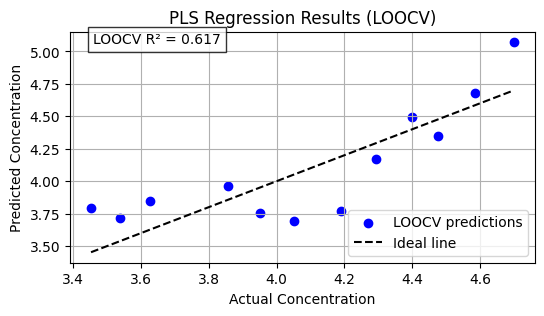


LOOCV Results:
Sample Actual Predicted Residual
1	4.400	4.493	0.093
2	4.293	4.174	-0.119
3	4.190	3.771	-0.419
4	4.700	5.071	0.371
5	4.585	4.680	0.094
6	4.476	4.345	-0.131
7	4.050	3.693	-0.357
8	3.951	3.757	-0.194
9	3.857	3.962	0.105
10	3.625	3.847	0.222
11	3.537	3.715	0.178
12	3.452	3.792	0.340


['scaler.joblib']

In [ ]:
## updated with white correction as in chat
import numpy as np
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d
from spectral import envi
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import LeaveOneOut, train_test_split
from sklearn.metrics import r2_score
from joblib import dump
import matplotlib.pyplot as plt

def load_reference(hdr_file, bin_file):
    """Load reference data from ENVI format files"""
    reference = envi.open(hdr_file, bin_file)
    return reference.load()

def apply_reference_correction(cube, white_ref, dark_ref):
    """
    Apply white and dark reference correction to hyperspectral cube
    Using formula: (Sample - Dark) / (White - Dark)
    """
    # Ensure references match cube dimensions
    if white_ref.shape != dark_ref.shape:
        raise ValueError("White and dark reference dimensions must match")
    
    # Broadcast references if needed
    if len(white_ref.shape) < len(cube.shape):
        white_ref = np.expand_dims(white_ref, axis=0)
        dark_ref = np.expand_dims(dark_ref, axis=0)
    
    # Avoid division by zero
    denominator = white_ref - dark_ref
   
    denominator[denominator == 0] = 1  # Avoid division by zero

    # Apply correction
    corrected = (cube - dark_ref) / denominator
    
    # Clip values to valid range [0, 1]
    corrected = np.clip(corrected, 0, 1)
    
    return corrected

# Load reference data
white_reference = load_reference('swiss/whiteReference.hdr', 'swiss/whiteReference.bin')
dark_reference = load_reference('swiss/darkReference.hdr', 'swiss/darkReference.bin')
# if data is in .hdr and .dat, just change .bin to .dat, but order should be preserved - first .hdr then .bin or .dat

# Find minimum dimensions across all cubes
min_height = min(cube.shape[0] for cube in cubes.values())
min_width = min(cube.shape[1] for cube in cubes.values())
min_bands = min(cube.shape[2] for cube in cubes.values())

# Crop and correct all cubes
cropped_cubes = {}
for name, cube in cubes.items():
    # Crop cube
    cropped = cube[:min_height, :min_width, :min_bands]
    # Apply reference correction
    corrected = apply_reference_correction(cropped, white_reference, dark_reference)
    cropped_cubes[name] = corrected

def process_cube(cube):
    """Process a single hyperspectral cube"""
    # First get spatial mean (across height and width)
    mean_spectrum = np.mean(cube, axis=(0, 1))
    
    # Apply preprocessing steps
    normalized = (mean_spectrum - np.min(mean_spectrum)) / (np.max(mean_spectrum) - np.min(mean_spectrum))
    smoothed = savgol_filter(normalized, 15, 3)
    denoised = gaussian_filter1d(smoothed, sigma=1)
    
    return denoised

# Process all cubes and create X matrix
X = np.zeros((len(cropped_cubes), min_bands))
for i, (name, cube) in enumerate(cropped_cubes.items()):
    X[i] = process_cube(cube)

# Convert concentrations to numpy array
y = np.array(concentrations)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize arrays to store predictions
y_pred = np.zeros_like(y)
loo = LeaveOneOut()

# Perform LOOCV
for train_idx, test_idx in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Fit PLS model
    pls = PLSRegression(n_components=5) # n_components=5 can be adjusted but 5 is the best for this dataset
    pls.fit(X_train, y_train)
    
    # Make prediction for left-out sample
    y_pred[test_idx] = pls.predict(X_test).ravel()

# Calculate R² score
r2 = r2_score(y, y_pred)

# Create regression plot
plt.figure(figsize=(6, 3))
plt.scatter(y, y_pred, c='blue', label='LOOCV predictions')
min_val, max_val = min(y), max(y)
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal line')
plt.xlabel('Actual Concentration')
plt.ylabel('Predicted Concentration')
plt.title('PLS Regression Results (LOOCV)')
plt.legend()
plt.grid(True)
plt.text(0.05, 0.95, f'LOOCV R² = {r2:.3f}', 
         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))
plt.show()

# Print LOOCV results
print("\nLOOCV Results:")
print("Sample Actual Predicted Residual")
for i in range(len(y)):
    print(f"{i+1}\t{y[i]:.3f}\t{y_pred[i]:.3f}\t{y_pred[i]-y[i]:.3f}")

# Save models
dump(pls, 'pls_model.joblib')
dump(scaler, 'scaler.joblib')


Below is testing of PLS regression on unseen files

/tmp/ipykernel_365987/3435667825.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white_ref - dark_ref
/tmp/ipykernel_365987/3435667825.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  corrected = (cube - dark_ref) / denominator


File: swiss/1_5_00ml
Actual concentration: 3.875
Predicted concentration: 3.736
Difference: -0.139



/tmp/ipykernel_365987/3435667825.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white_ref - dark_ref
/tmp/ipykernel_365987/3435667825.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  corrected = (cube - dark_ref) / denominator


File: swiss/1_5_05ml
Actual concentration: 3.780
Predicted concentration: 3.890
Difference: 0.110



/tmp/ipykernel_365987/3435667825.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white_ref - dark_ref
/tmp/ipykernel_365987/3435667825.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  corrected = (cube - dark_ref) / denominator


File: swiss/1_5_10ml
Actual concentration: 3.690
Predicted concentration: 4.009
Difference: 0.319



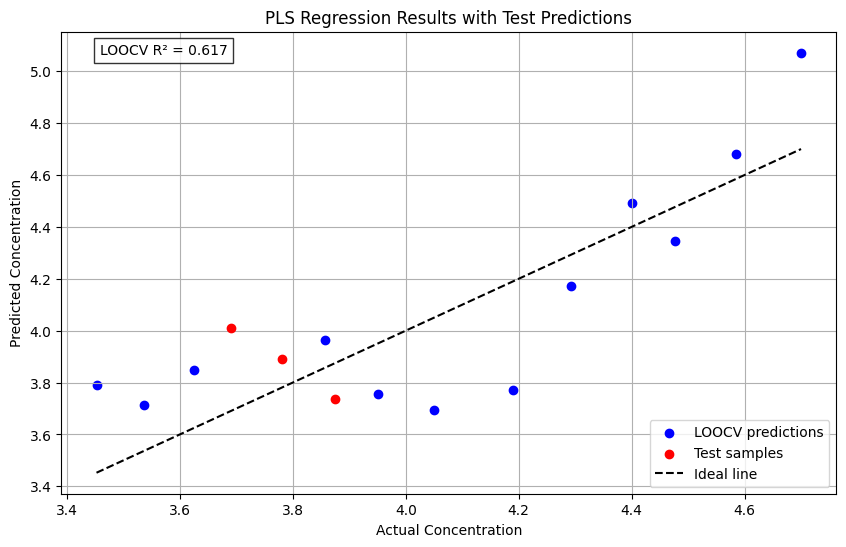


Test Set Results:

Detailed Predictions:
Sample 1:
Actual: 3.875
Predicted: 3.736
Difference: -0.139

Sample 2:
Actual: 3.780
Predicted: 3.890
Difference: 0.110

Sample 3:
Actual: 3.690
Predicted: 4.009
Difference: 0.319



In [9]:
test_files = [
    ('swiss/1_5_00ml', 3.875),
    ('swiss/1_5_05ml', 3.78),
    ('swiss/1_5_10ml', 3.69)
]

predictions = []
actuals = []

# Process each file
for filepath, actual_conc in test_files:
    # Read and process the file
    new_cube = envi.open(f'{filepath}.hdr', f'{filepath}.bin')
    new_data = new_cube.load()
    
    # Crop to minimum height
    new_data = new_data[:min_height, :, :]
    
    # Apply white and black reference correction
    new_data_corrected = apply_reference_correction(new_data, white_reference, dark_reference)
    
    # Process the corrected cube
    new_spectrum = process_cube(new_data_corrected)
    new_spectrum_scaled = scaler.transform(new_spectrum.reshape(1, -1))
    
    # Make prediction
    new_pred = pls.predict(new_spectrum_scaled)[0]
    print(f"File: {filepath}")
    print(f"Actual concentration: {actual_conc:.3f}")
    print(f"Predicted concentration: {new_pred:.3f}")
    print(f"Difference: {new_pred - actual_conc:.3f}\n")
    
    predictions.append(new_pred)
    actuals.append(actual_conc)

# Create visualization
plt.figure(figsize=(10, 6))

# Plot LOOCV results
plt.scatter(y, y_pred, c='blue', label='LOOCV predictions')

# Plot new predictions
plt.scatter(actuals, predictions, c='red', label='Test samples', zorder=3)

# Plot ideal line
min_val = min(min(y), min(actuals))
max_val = max(max(y), max(actuals))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal line')

plt.xlabel('Actual Concentration')
plt.ylabel('Predicted Concentration')
plt.title('PLS Regression Results with Test Predictions')
plt.legend()
plt.grid(True)

# Display R² score
plt.text(0.05, 0.95, f'LOOCV R² = {r2:.3f}', 
         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))

plt.show()

# Calculate test set metrics
test_r2 = r2_score(actuals, predictions)
print("\nTest Set Results:")
#print(f"Test Set R²: {test_r2:.3f}")
print("\nDetailed Predictions:")
for i, (actual, pred) in enumerate(zip(actuals, predictions)):
    print(f"Sample {i+1}:")
    print(f"Actual: {actual:.3f}")
    print(f"Predicted: {pred:.3f}")
    print(f"Difference: {pred - actual:.3f}")
    print()